In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import camelot

In [6]:
archivo = './Dataset/Analisis Anual 2018 ETAS.pdf'

In [7]:
tabla = camelot.read_pdf(archivo, pages = '3')
tabla

<TableList n=1>

In [8]:
tabla[0].df

,0,1,2,3,4
0,AREA DE SALUD,2017,,2018,
1,,Casos,Tasas,Casos,Tasas
2,Ixcán \nSan Marcos \nIxil \nChiquimula \nSanta...,12777 \n64916 \n16229 \n25517 \n22257,10747.00 \n5531.76 \n8131.17 \n5995.79 \n5698.26,15484 \n83219 \n14009 \n28873 \n25857,12559.72 \n6937.18 \n6775.49 \n6629.64 \n6485.10
3,Zacapa \nHuehuetenango \nPetén Sur Occidental ...,13467 \n85754 \n14539 \n10657 \n15657 \n22885 ...,5499.70 \n6443.15 \n4960.76 \n4312.31 \n4504.7...,16111 \n87211 \n18107 \n14694 \n19647 \n32402 ...,6464.70 \n6409.30 \n5980.51 \n5787.55 \n5533.6...
4,Total País,662901,3914.98,756338,4369.10


In [29]:
# areas = tabla[0].df[0][2].split('\n')
# [x.strip() for x in areas]

areas = list(map (lambda area: area.strip(), tabla[0].df[0][2].split('\n')))
areas.extend(list(map (lambda area: area.strip(), tabla[0].df[0][3].split('\n'))))

casos17 = list(map(lambda caso: int(caso.strip()), tabla[0].df[1][2].split('\n')))
casos17.extend(list(map(lambda caso: int(caso.strip()), tabla[0].df[1][3].split('\n'))))

tasas17 = [float(tasa.strip()) for tasa in tabla[0].df[2][2].split('\n')]
tasas17.extend([float(tasa.strip()) for tasa in tabla[0].df[2][3].split('\n')])

casos18 = list(map(lambda caso: int(caso.strip()), tabla[0].df[3][2].split('\n')))
casos18.extend(list(map(lambda caso: int(caso.strip()), tabla[0].df[3][3].split('\n'))))

tasas18 = [float(tasa.strip()) for tasa in tabla[0].df[4][2].split('\n')]
tasas18.extend([float(tasa.strip()) for tasa in tabla[0].df[4][3].split('\n')])


In [35]:
etas = pd.DataFrame({
    'Área de Salud': areas,
    'Casos \'17': casos17,
    'Tasas \'17': tasas17,
    'Casos \'18': casos18,
    'Tasas \'18': tasas18
})

In [37]:
etas.describe()

,Casos '17,Tasas '17,Casos '18,Tasas '18
count,29.000000,29.000000,29.000000,29.000000
mean,22858.655172,4319.882414,26080.620690,4782.187931
std,17573.564154,2037.263456,20209.094508,2284.237179
min,7520.000000,1411.860000,8345.000000,1416.070000
25%,12777.000000,3293.580000,14370.000000,3233.510000
50%,16229.000000,4298.090000,18107.000000,5165.630000
75%,22885.000000,5499.700000,28873.000000,5980.510000
max,85754.000000,10747.000000,87211.000000,12559.720000


<Axes: >

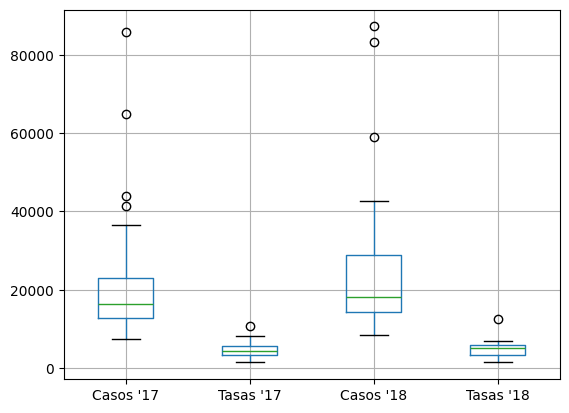

In [38]:
etas.boxplot()

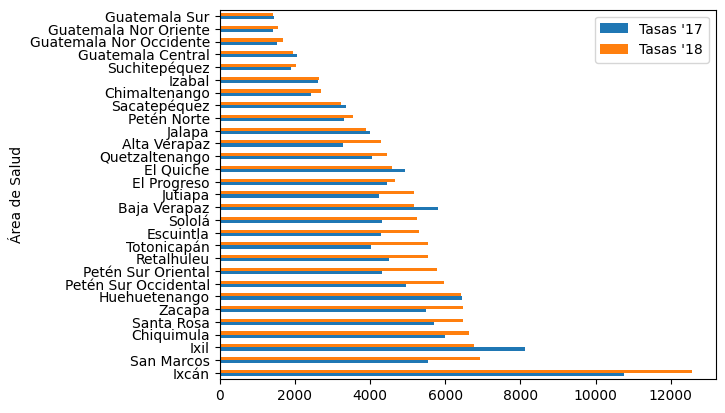

In [42]:
etas.plot(x='Área de Salud', y = ['Tasas \'17', 'Tasas \'18'], kind = 'barh')
# De esta forma trazará 2 líneas diferentes 
plt.show()